# Análisis Exploratorio de Datos (EDA) — Beijing PM2.5

## Descripción del problema

Este notebook realiza un **Análisis Exploratorio de Datos (EDA)** sobre el dataset *Beijing PM2.5 Data Set* del repositorio UCI Machine Learning Repository:

🔗 https://archive.ics.uci.edu/dataset/381/beijing+pm2+5+data

### Contexto

El dataset contiene mediciones **horarias** de la concentración de partículas finas **PM2.5** (material particulado de diámetro ≤ 2.5 µm) registradas en la **Embajada de Estados Unidos en Beijing**, junto con datos meteorológicos del aeropuerto internacional capital de Beijing. El periodo cubierto es del **1 de enero de 2010 al 31 de diciembre de 2014** (5 años, ~43,824 registros).

Las partículas PM2.5 son uno de los principales indicadores de calidad del aire y están directamente asociadas con problemas respiratorios y cardiovasculares en la población. Predecir su concentración a partir de variables meteorológicas es un problema clásico de regresión / series temporales.

### Variables del dataset

| Columna | Descripción | Tipo |
|---|---|---|
| `No` | Número de fila | int |
| `year` | Año (2010–2014) | int |
| `month` | Mes (1–12) | int |
| `day` | Día del mes | int |
| `hour` | Hora (0–23) | int |
| `pm2.5` | Concentración de PM2.5 (µg/m³) — **variable objetivo** | float |
| `DEWP` | Punto de rocío (°C) | int |
| `TEMP` | Temperatura (°C) | int |
| `PRES` | Presión atmosférica (hPa) | int |
| `cbwd` | Dirección del viento combinada (NE, NW, SE, cv) | categórica |
| `Iws` | Velocidad acumulada del viento (m/s) | float |
| `Is` | Horas acumuladas de nieve | int |
| `Ir` | Horas acumuladas de lluvia | int |

### Objetivo del EDA

Este EDA es el paso previo a entrenar un modelo de **Machine Learning / Deep Learning** (típicamente regresión sobre `pm2.5`). Cubre:

1. Carga e inspección inicial de los datos.
2. Diagnóstico de calidad: nulos, duplicados, tipos.
3. Estadísticas descriptivas.
4. Análisis univariado (distribuciones).
5. Análisis bivariado (correlaciones, target vs features).
6. Análisis temporal (estacionalidad anual, mensual, horaria).
7. Detección de outliers.
8. Conclusiones y recomendaciones para la fase de modelado.

In [2]:
# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración global de gráficos
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11

# Mostrar más columnas/filas en pandas al imprimir
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 120)

# Reproducibilidad
#np.random.seed(42)


## Carga de datos e inspección inicial

Leemos el archivo CSV. 
Antes de hacer cualquier análisis, identificamos que tipos de datos y la información general del DataFrame. 

In [4]:
# Ruta al archivo (ajusta si lo tienes en otra ubicación)
RUTA_CSV = r"C:\Users\licen\Documentos\00_AI_Bootcamp\PRSA_data_2010.1.1-2014.12.31.csv"

# Cargar el CSV
df = pd.read_csv(RUTA_CSV)

# Confirmación rápida
print(f"Dataset cargado. Forma: {df.shape[0]:,} filas × {df.shape[1]} columnas")

Dataset cargado. Forma: 43,824 filas × 13 columnas


## 3. Inspección inicial



In [5]:
# Primeras 5 filas
df.head()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [6]:
# Últimas 5 filas (verificar que el dataset termina como se espera)
df.tail()

,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
43819,43820,2014,12,31,19,8.0,-23,-2.0,1034.0,NW,231.97,0,0
43820,43821,2014,12,31,20,10.0,-22,-3.0,1034.0,NW,237.78,0,0
43821,43822,2014,12,31,21,10.0,-22,-3.0,1034.0,NW,242.70,0,0
43822,43823,2014,12,31,22,8.0,-22,-4.0,1034.0,NW,246.72,0,0
43823,43824,2014,12,31,23,12.0,-21,-3.0,1034.0,NW,249.85,0,0


In [7]:
# Información general: tipos, nulos, memoria
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43824 entries, 0 to 43823
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   No      43824 non-null  int64  
 1   year    43824 non-null  int64  
 2   month   43824 non-null  int64  
 3   day     43824 non-null  int64  
 4   hour    43824 non-null  int64  
 5   pm2.5   41757 non-null  float64
 6   DEWP    43824 non-null  int64  
 7   TEMP    43824 non-null  float64
 8   PRES    43824 non-null  float64
 9   cbwd    43824 non-null  object 
 10  Iws     43824 non-null  float64
 11  Is      43824 non-null  int64  
 12  Ir      43824 non-null  int64  
dtypes: float64(4), int64(8), object(1)
memory usage: 4.3+ MB


In [8]:
# Construir la columna datetime a partir de year/month/day/hour
df["datetime"] = pd.to_datetime(df[["year", "month", "day", "hour"]])

# Descartar la columna 'No' (es solo un id de fila, no aporta información)
df = df.drop(columns=["No"])

# Establecer el índice temporal y ordenar por si acaso
df = df.set_index("datetime").sort_index()

print(f"Rango temporal: {df.index.min()} → {df.index.max()}")
print(f"Frecuencia esperada: horaria (1H)")
print(f"Total de horas en el rango: {(df.index.max() - df.index.min()).total_seconds() / 3600 + 1:,.0f}")
print(f"Filas en el dataset:        {len(df):,}")
df.head()

Rango temporal: 2010-01-01 00:00:00 → 2014-12-31 23:00:00
Frecuencia esperada: horaria (1H)
Total de horas en el rango: 43,824
Filas en el dataset:        43,824


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
datetime,,,,,,,,,,,,
2010-01-01 00:00:00,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


## Análisis de Calidad de los datos

### Valores nulos

El campo `pm2.5` es notorio en este dataset por tener una cantidad importante de nulos (la estación no registró durante varias horas). Hay que cuantificarlos antes de decidir cómo tratarlos.

In [9]:
# Cantidad y porcentaje de nulos por columna
nulos = pd.DataFrame({
    "nulos": df.isnull().sum(),
    "% nulos": (df.isnull().sum() / len(df) * 100).round(2)
})
nulos.sort_values("nulos", ascending=False)

,nulos,% nulos
pm2.5,2067,4.72
year,0,0.00
day,0,0.00
month,0,0.00
hour,0,0.00
DEWP,0,0.00
TEMP,0,0.00
PRES,0,0.00
cbwd,0,0.00
Iws,0,0.00


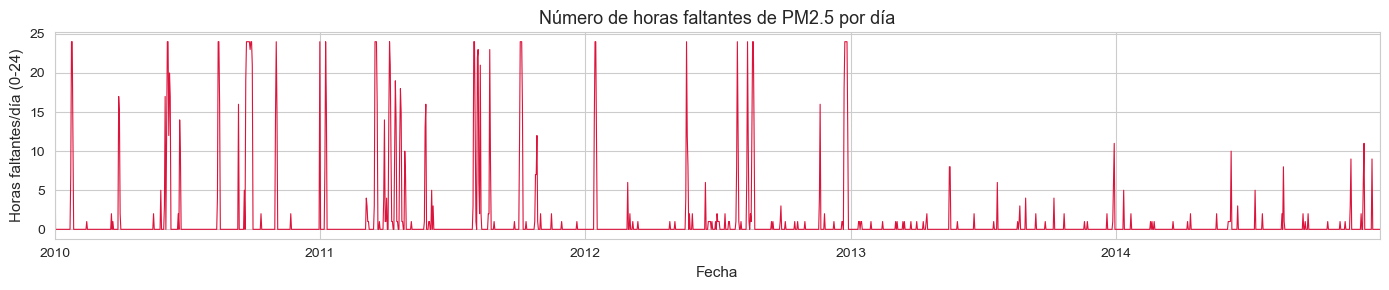

In [12]:
# Visualizar dónde están los nulos de pm2.5 a lo largo del tiempo
# Si están concentrados en periodos específicos o son aleatorios, eso afecta la estrategia de imputación
fig, ax = plt.subplots(figsize=(14, 3))
df["pm2.5"].isnull().astype(int).resample("D").sum().plot(ax=ax, color="crimson", lw=0.8)
ax.set_title("Número de horas faltantes de PM2.5 por día")
ax.set_ylabel("Horas faltantes/día (0-24)")
ax.set_xlabel("Fecha")
plt.tight_layout()
plt.show()

# Estan mas bien distribuidos, aunque en los primeros años si es mas alto del procentaje de horas faltantes

### Revisión de duplicados

Verificamos también si hay timestamps duplicados (no debería haberlos en un dataset horario bien formado).

In [ ]:
print(f"Filas duplicadas exactas: {df.duplicated().sum()}")
print(f"Timestamps duplicados:    {df.index.duplicated().sum()}")
# No hay! genial

Filas duplicadas exactas: 0
Timestamps duplicados:    0


## Estadística descriptiva
Cómo se comportan estas variables???
Para una visión rápida de la escala, dispersión y posibles outliers de cada variable numérica. 

In [13]:
# Estadísticas de variables numéricas
df.describe().T.round(2)

,count,mean,std,min,25%,50%,75%,max
year,43824.0,2012.00,1.41,2010.00,2011.00,2012.00,2013.00,2014.0
month,43824.0,6.52,3.45,1.00,4.00,7.00,10.00,12.0
day,43824.0,15.73,8.80,1.00,8.00,16.00,23.00,31.0
hour,43824.0,11.50,6.92,0.00,5.75,11.50,17.25,23.0
pm2.5,41757.0,98.61,92.05,0.00,29.00,72.00,137.00,994.0
DEWP,43824.0,1.82,14.43,-40.00,-10.00,2.00,15.00,28.0
TEMP,43824.0,12.45,12.20,-19.00,2.00,14.00,23.00,42.0
PRES,43824.0,1016.45,10.27,991.00,1008.00,1016.00,1025.00,1046.0
Iws,43824.0,23.89,50.01,0.45,1.79,5.37,21.91,585.6
Is,43824.0,0.05,0.76,0.00,0.00,0.00,0.00,27.0


In [ ]:
# Como hay viento...esta es mejor verla con la frecuencia de la variable... 
# Frecuencia de la variable categórica 'cbwd' (dirección del viento)
# NE = noreste, NW = noroeste, SE = sureste, cv = calm/variable
df["cbwd"].value_counts(dropna=False)

cbwd
SE    15290
NW    14150
cv     9387
NE     4997
Name: count, dtype: int64

## Análisis univariado

Identificar distribución de cada variable individualmente. Los features son simétricos?, sesgados?, multimodales?, o si tienen colas largas — esto todo es para ver... que transformaciones son mejores antes de ingresar las variables a un modelo

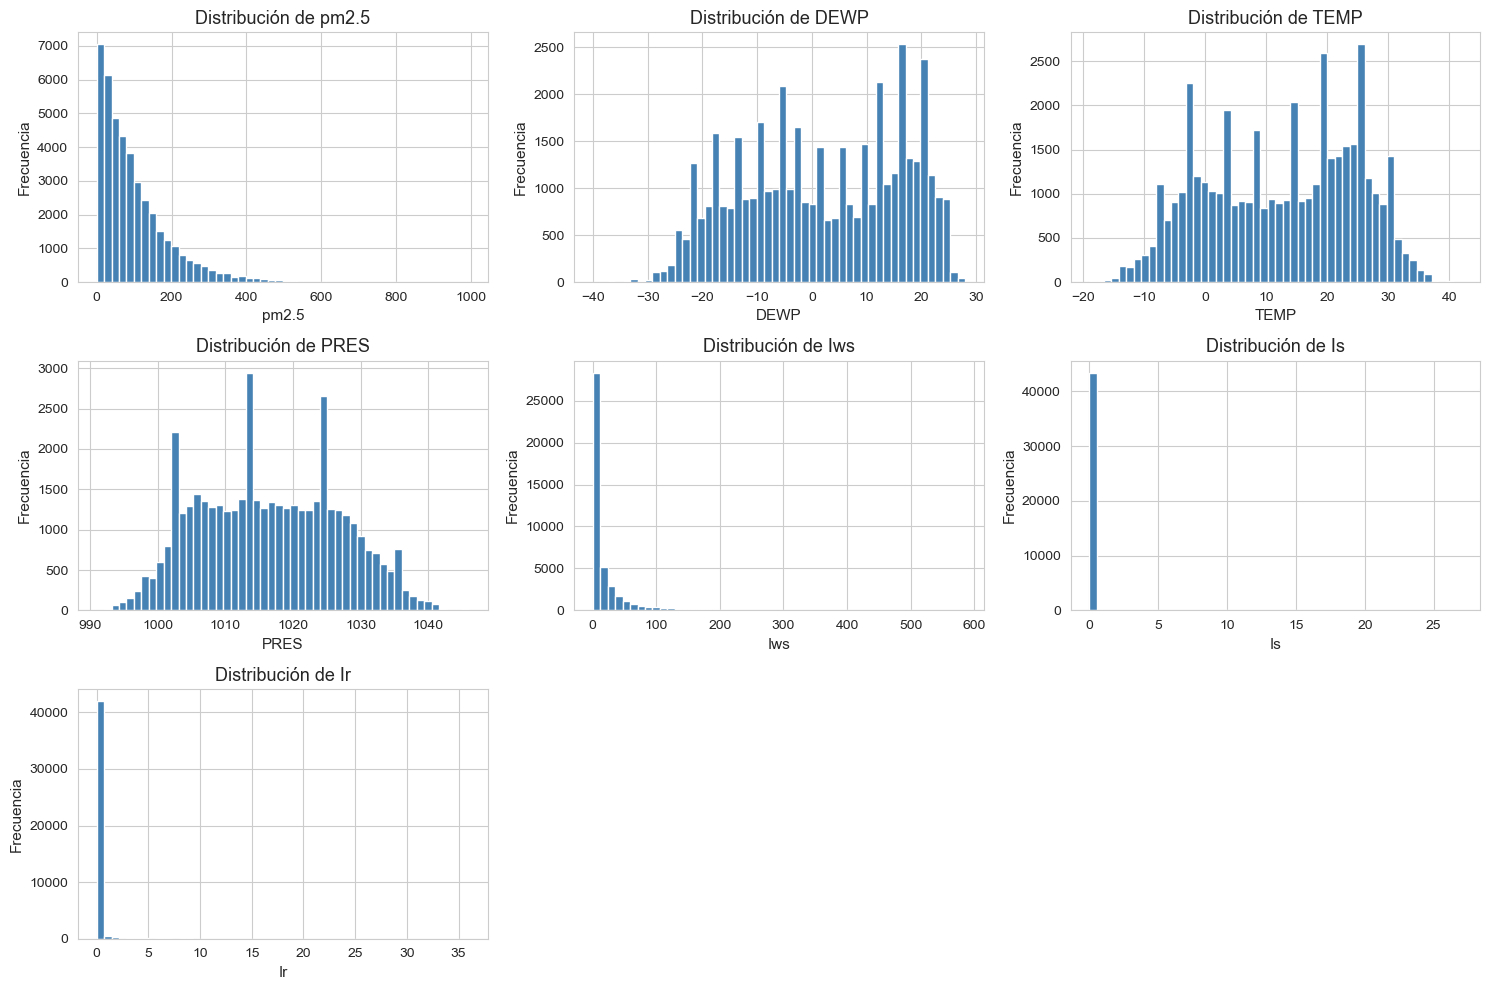

In [15]:
# Histogramas de todas las variables numéricas
variables_numericas = ["pm2.5", "DEWP", "TEMP", "PRES", "Iws", "Is", "Ir"]

fig, axes = plt.subplots(3, 3, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].hist(df[col].dropna(), bins=50, color="steelblue", edgecolor="white")
    axes[i].set_title(f"Distribución de {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frecuencia")

# Ocultar los ejes sobrantes
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

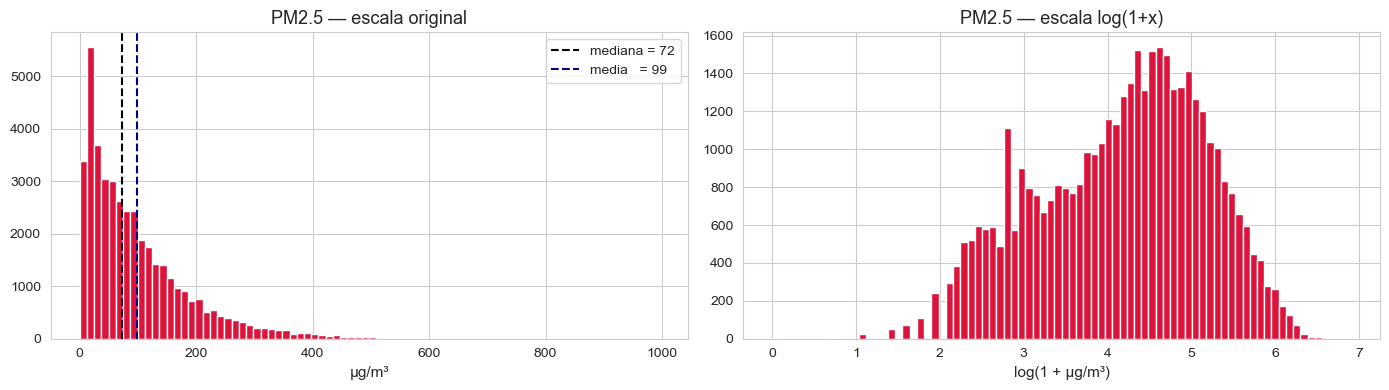

In [16]:
# Distribución detallada del target: pm2.5
# Mostramos también la versión log-transformada porque la variable está fuertemente sesgada a la derecha
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df["pm2.5"].dropna(), bins=80, color="crimson", edgecolor="white")
axes[0].set_title("PM2.5 — escala original")
axes[0].set_xlabel("µg/m³")
axes[0].axvline(df["pm2.5"].median(), color="black", linestyle="--", label=f"mediana = {df['pm2.5'].median():.0f}")
axes[0].axvline(df["pm2.5"].mean(),   color="navy",  linestyle="--", label=f"media   = {df['pm2.5'].mean():.0f}")
axes[0].legend()

# log1p evita problemas con los ceros
axes[1].hist(np.log1p(df["pm2.5"].dropna()), bins=80, color="crimson", edgecolor="white")
axes[1].set_title("PM2.5 — escala log(1+x)")
axes[1].set_xlabel("log(1 + µg/m³)")

plt.tight_layout()
plt.show()

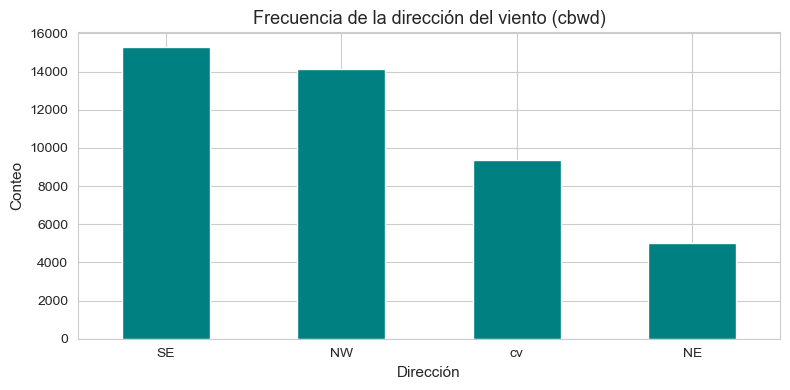

In [17]:
# Frecuencia de la dirección del viento
fig, ax = plt.subplots(figsize=(8, 4))
df["cbwd"].value_counts().plot(kind="bar", ax=ax, color="teal", edgecolor="white")
ax.set_title("Frecuencia de la dirección del viento (cbwd)")
ax.set_xlabel("Dirección")
ax.set_ylabel("Conteo")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Análisis bivariado ... ver como se relacionan entre las variables elegidas

### Matriz de correlación
Es el primer filtro de los features!!

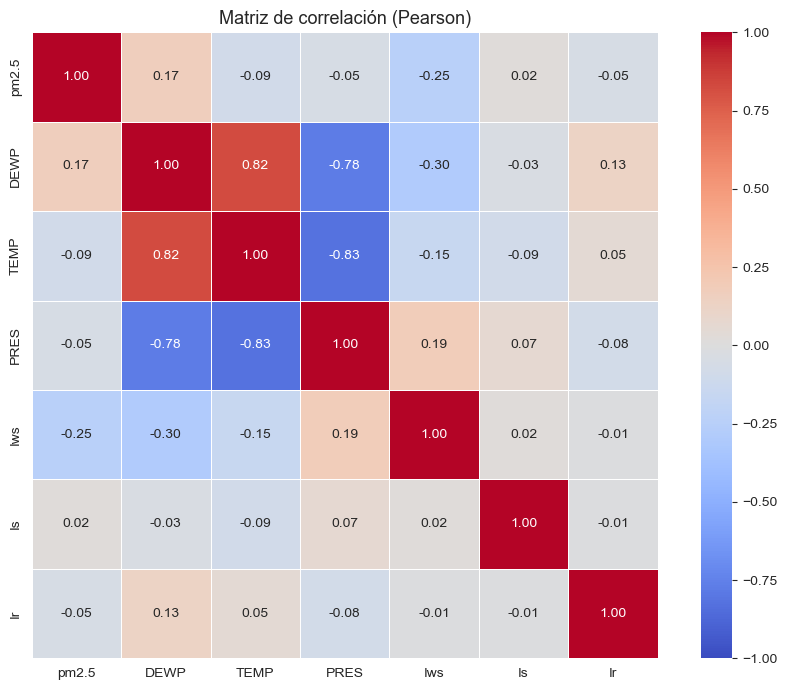

In [18]:
# Calcular la matriz de correlación solo sobre numéricas
corr = df[variables_numericas].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm", center=0,
    vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    ax=ax
)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

In [19]:
# Correlaciones específicamente contra el target ordenadas por magnitud absoluta
corr_target = df[variables_numericas].corr()["pm2.5"].drop("pm2.5")
corr_target = corr_target.reindex(corr_target.abs().sort_values(ascending=False).index)
print("Correlación de cada feature con pm2.5:")
print(corr_target.round(3))

Correlación de cada feature con pm2.5:
Iws    -0.248
DEWP    0.171
TEMP   -0.091
Ir     -0.051
PRES   -0.047
Is      0.019
Name: pm2.5, dtype: float64


### PM2.5 vs variables continuas

Scatter plots para ver visualmente la forma de la relación (lineal, no lineal, ruido). Submuestreamos para que los gráficos sean legibles — con ~43k puntos el plot completo se vuelve una mancha.

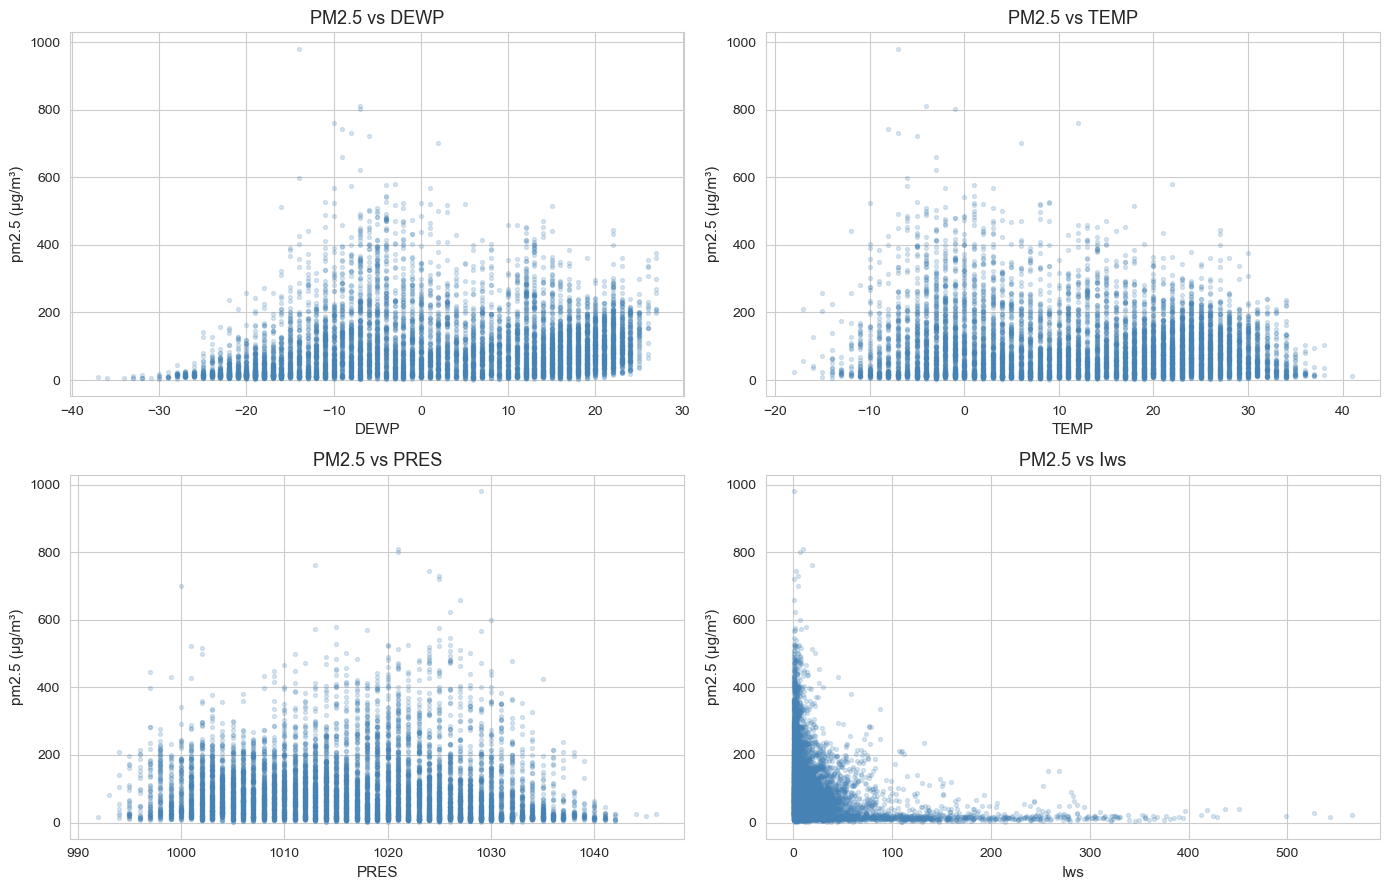

In [20]:
# Submuestreo aleatorio del 20% solo para visualización
df_sample = df.dropna(subset=["pm2.5"]).sample(frac=0.2, random_state=42)

features_continuas = ["DEWP", "TEMP", "PRES", "Iws"]
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(features_continuas):
    axes[i].scatter(df_sample[col], df_sample["pm2.5"], alpha=0.2, s=8, color="steelblue")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("pm2.5 (µg/m³)")
    axes[i].set_title(f"PM2.5 vs {col}")

plt.tight_layout()
plt.show()

### PM2.5 vs variable categórica (dirección del viento)

La dirección del viento es uno de los factores más relevantes en la calidad del aire de Beijing — el viento del NW suele traer aire limpio desde Mongolia, mientras que los vientos del SE traen contaminación de las zonas industriales del sur.

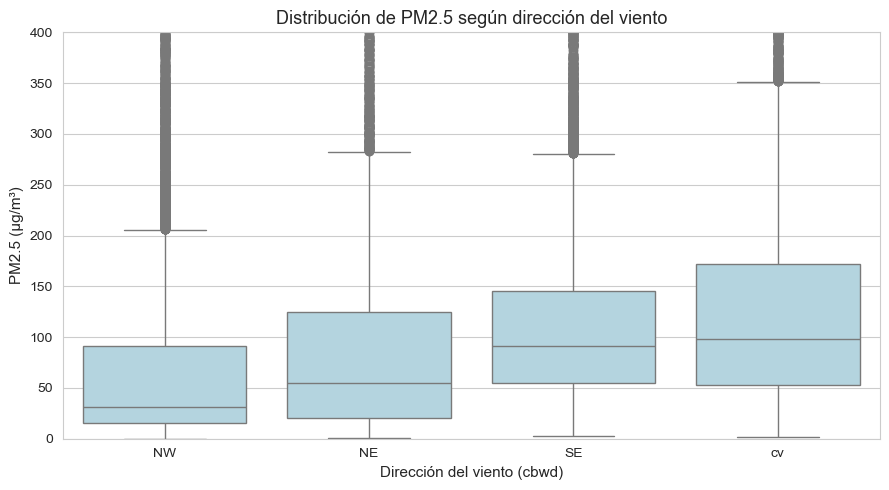

,count,mean,median,std
cbwd,,,,
NE,4756,90.2,55.0,95.2
NW,13484,70.1,31.0,89.1
SE,14573,110.8,91.0,80.1
cv,8944,126.2,98.0,100.4


In [21]:
# Boxplot de PM2.5 por dirección del viento
fig, ax = plt.subplots(figsize=(9, 5))
orden = df.groupby("cbwd")["pm2.5"].median().sort_values().index
sns.boxplot(data=df, x="cbwd", y="pm2.5", order=orden, ax=ax, color="lightblue")
ax.set_title("Distribución de PM2.5 según dirección del viento")
ax.set_xlabel("Dirección del viento (cbwd)")
ax.set_ylabel("PM2.5 (µg/m³)")
# Limitar eje y para que los outliers no aplasten la caja
ax.set_ylim(0, 400)
plt.tight_layout()
plt.show()

# Estadísticas numéricas por dirección
df.groupby("cbwd")["pm2.5"].agg(["count", "mean", "median", "std"]).round(1)

## Análisis temporal

Al ser una serie temporal, conviene mirar tendencias y estacionalidad a varias escalas: anual, mensual, día de la semana y hora del día. Esto orientará el feature engineering temporal (variables cíclicas, lags, medias móviles, etc.).

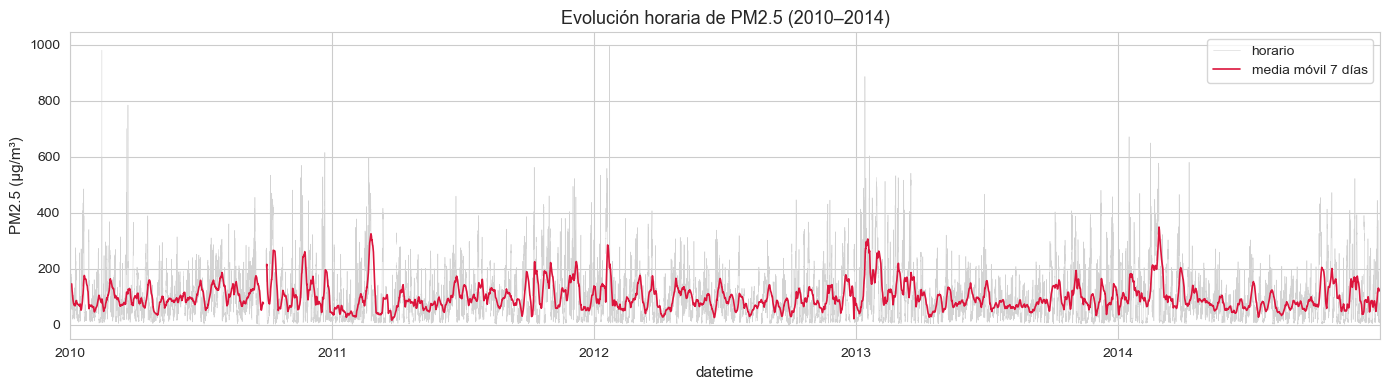

In [22]:
# Serie temporal completa con suavizado (media móvil de 7 días) para ver la tendencia
fig, ax = plt.subplots(figsize=(14, 4))
df["pm2.5"].plot(ax=ax, color="lightgray", lw=0.4, label="horario")
df["pm2.5"].rolling(window=24*7, min_periods=24).mean().plot(
    ax=ax, color="crimson", lw=1.2, label="media móvil 7 días"
)
ax.set_title("Evolución horaria de PM2.5 (2010–2014)")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend()
plt.tight_layout()
plt.show()

In [23]:
# Crear columnas auxiliares de fecha para el análisis estacional
df_t = df.copy()
df_t["year"]    = df_t.index.year
df_t["month"]   = df_t.index.month
df_t["weekday"] = df_t.index.dayofweek    # 0=lunes, 6=domingo
df_t["hour"]    = df_t.index.hour

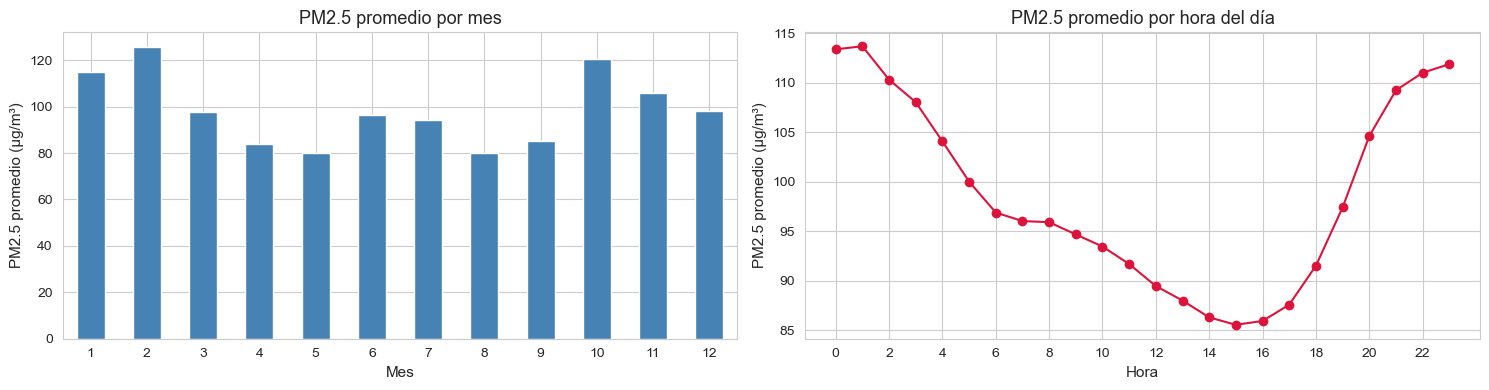

In [24]:
# Estacionalidad por mes y por hora del día
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Por mes — esperamos picos en invierno (calefacción con carbón) y mínimos en verano
df_t.groupby("month")["pm2.5"].mean().plot(
    kind="bar", ax=axes[0], color="steelblue", edgecolor="white"
)
axes[0].set_title("PM2.5 promedio por mes")
axes[0].set_xlabel("Mes")
axes[0].set_ylabel("PM2.5 promedio (µg/m³)")
axes[0].set_xticklabels(range(1, 13), rotation=0)

# Por hora del día — esperamos patrón ligado a tráfico y a la capa límite atmosférica
df_t.groupby("hour")["pm2.5"].mean().plot(
    kind="line", ax=axes[1], color="crimson", marker="o"
)
axes[1].set_title("PM2.5 promedio por hora del día")
axes[1].set_xlabel("Hora")
axes[1].set_ylabel("PM2.5 promedio (µg/m³)")
axes[1].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

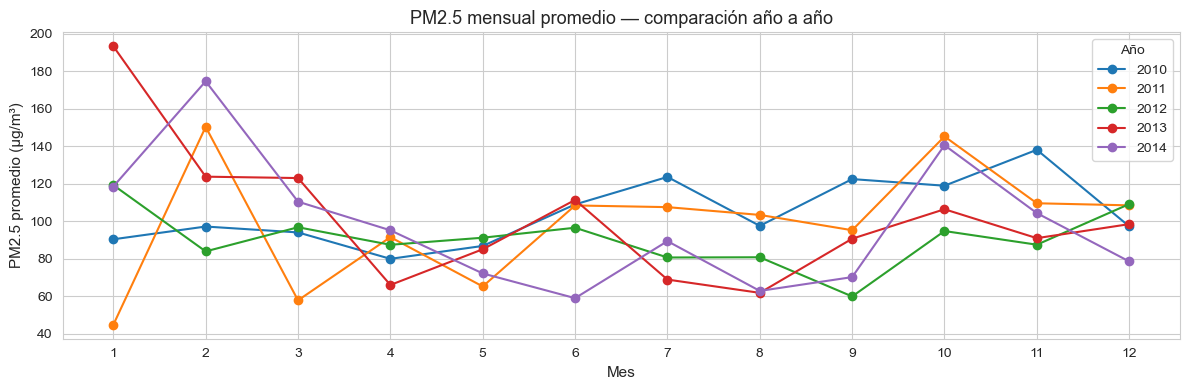

In [25]:
# Comparación año contra año — ¿hubo mejora o empeoramiento de la calidad del aire?
fig, ax = plt.subplots(figsize=(12, 4))
df_t.groupby(["year", "month"])["pm2.5"].mean().unstack("year").plot(ax=ax, marker="o")
ax.set_title("PM2.5 mensual promedio — comparación año a año")
ax.set_xlabel("Mes")
ax.set_ylabel("PM2.5 promedio (µg/m³)")
ax.set_xticks(range(1, 13))
ax.legend(title="Año")
plt.tight_layout()
plt.show()

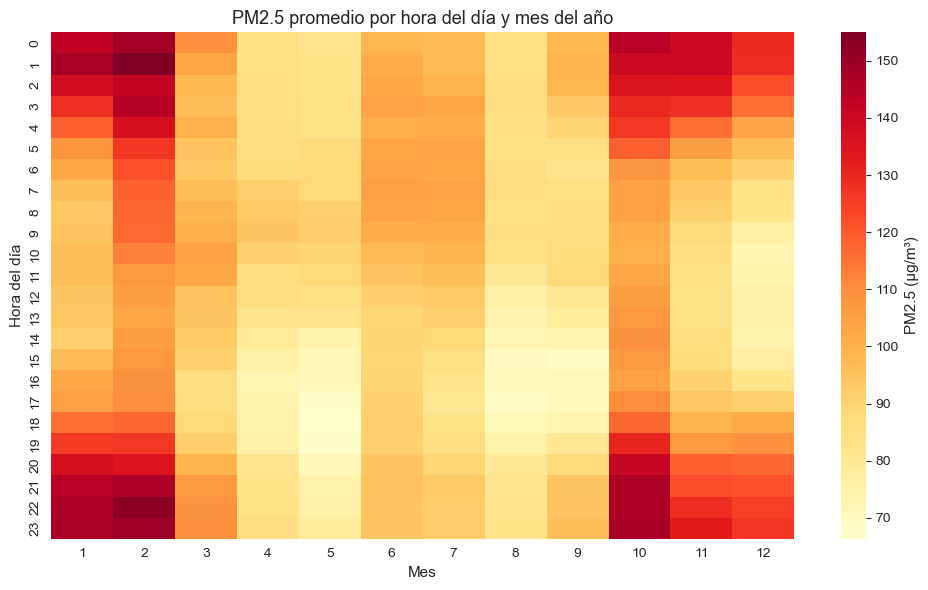

In [26]:
# Heatmap mes × hora — útil para ver simultáneamente las dos estacionalidades dominantes
pivot = df_t.pivot_table(values="pm2.5", index="hour", columns="month", aggfunc="mean")
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(pivot, cmap="YlOrRd", ax=ax, cbar_kws={"label": "PM2.5 (µg/m³)"})
ax.set_title("PM2.5 promedio por hora del día y mes del año")
ax.set_xlabel("Mes")
ax.set_ylabel("Hora del día")
plt.tight_layout()
plt.show()

## Detección de outliers

Boxplots para localizar outliers en cada variable numérica. Estos son en los que hizo mucho enfasis el profesor.
En este dataset los "outliers" altos de PM2.5 son **reales** (corresponden a episodios de smog severo) — no se deben eliminar a la ligera, pero sí conviene tener en mente la transformación logarítmica o modelos robustos.

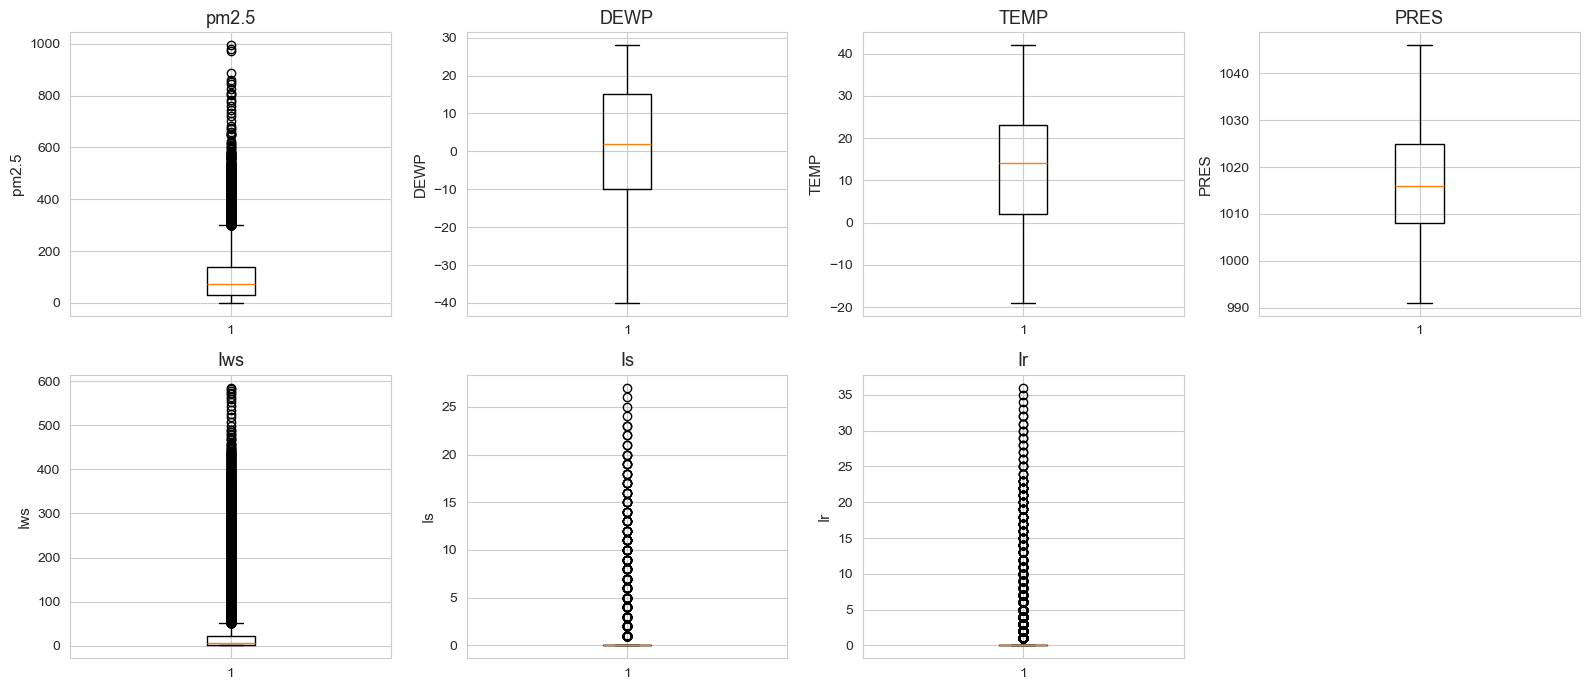

In [27]:
# Boxplots de las variables numéricas
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()

for i, col in enumerate(variables_numericas):
    axes[i].boxplot(df[col].dropna(), vert=True)
    axes[i].set_title(col)
    axes[i].set_ylabel(col)

# Ocultar el último subplot vacío
for j in range(len(variables_numericas), len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

In [28]:
# Cuantificar outliers con la regla de Tukey (1.5 * IQR)
def contar_outliers_iqr(serie):
    s = serie.dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    bajo, alto = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < bajo) | (s > alto)).sum()
    return pd.Series({"n_outliers": n_out, "% outliers": round(100 * n_out / len(s), 2),
                      "limite_inf": round(bajo, 2), "limite_sup": round(alto, 2)})

tabla_out = pd.DataFrame({col: contar_outliers_iqr(df[col]) for col in variables_numericas}).T
tabla_out

,n_outliers,% outliers,limite_inf,limite_sup
pm2.5,1773.0,4.25,-133.00,299.00
DEWP,0.0,0.00,-47.50,52.50
TEMP,0.0,0.00,-29.50,54.50
PRES,0.0,0.00,982.50,1050.50
Iws,5101.0,11.64,-28.39,52.09
Is,368.0,0.84,0.00,0.00
Ir,1808.0,4.13,0.00,0.00


## 11. Conclusiones del EDA y recomendaciones para modelado

### Qué encontramos

- **Tamaño**: ~43,800 registros horarios sobre 5 años (cobertura completa del rango temporal).
- **Calidad**: la única variable con nulos significativos es el **target `pm2.5`** (~5%). El resto está completo.
- **Distribución del target**: muy **sesgada a la derecha**, con cola larga hacia valores extremos (>500 µg/m³) en episodios de smog. La transformación `log(1+x)` la normaliza notablemente.
- **Correlaciones lineales con el target**: moderadas y todas en magnitudes pequeñas — la más fuerte es `Iws` (velocidad acumulada del viento) en sentido negativo (más viento → menos PM2.5), seguida de `DEWP`, `PRES` y `TEMP`. Esto sugiere que las relaciones son **no lineales** y modelos como Random Forest, XGBoost o redes neuronales tendrán ventaja sobre regresión lineal.
- **Estacionalidad clara**: niveles más altos en **invierno** (calefacción con carbón) y más bajos en verano; perfil horario con doble pico en mañana/noche.
- **Dirección del viento**: el viento del **NW** trae aire limpio, los vientos `cv` (calma) y del SE coinciden con los peores niveles. Variable categórica con poder predictivo claro.
- **Outliers**: el ~7% de las observaciones de PM2.5 caen fuera del IQR, pero son **eventos reales** (no errores de medición).

### Recomendaciones para la fase de modelado (ML/DL)

**Limpieza e imputación**
- Para los nulos de `pm2.5`: como es el target, lo más limpio es **eliminar esas filas** del set de entrenamiento (no se puede entrenar sin etiqueta). Si se quisiera predecirlos, sería un problema separado de imputación.
- Verificar que no queden gaps al construir variables de lag.

**Feature engineering**
- Codificar `cbwd` con one-hot encoding (4 categorías).
- Codificar `hour` y `month` como variables **cíclicas** con seno/coseno (`sin(2π·hora/24)`, `cos(2π·hora/24)`) en lugar de ordinales.
- Crear **lags** del target (`pm2.5_t-1`, `pm2.5_t-24`, etc.) para modelos de series temporales.
- Considerar **medias móviles** y diferencias (`Iws_diff`) como features adicionales.

**Transformaciones**
- Aplicar `log(1+x)` al target para entrenamiento (revertir con `expm1` para evaluar).
- Estandarizar (`StandardScaler`) las variables continuas para modelos sensibles a escala (redes neuronales, SVM, KNN).

**Validación**
- **No usar K-Fold aleatorio**: es serie temporal, hay que usar split cronológico (`TimeSeriesSplit` de sklearn) o un walk-forward para no contaminar el entrenamiento con información futura.

**Modelos sugeridos como punto de partida**
1. Línea base: regresión lineal o `Ridge` con feature engineering.
2. **Gradient Boosting** (`XGBoost`, `LightGBM`) — suele ser el ganador en datasets tabulares con relaciones no lineales.
3. **LSTM / GRU** o **Temporal Fusion Transformer** si se quiere explotar la estructura temporal pura.

**Métrica**
- RMSE o MAE en escala original; reportar también MAPE con cuidado (puede explotar cerca de cero).

---

Con esto, los datos ya están entendidos y listos para pasar a las etapas de **preprocesamiento → entrenamiento → evaluación → tuning**.